In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes', 'gymnasium']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact'), 'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Learning from Demonstrations

Dynamic programming assumes access to the transition kernel and reward. Imitation learning instead assumes access to demonstrations from an expert. *Behavior cloning* fits a policy to demonstrated state--action pairs as a supervised classification problem. Although this policy can fit its training data perfectly, its own actions may take it to states that were rare or absent in the demonstrations. We study the resulting distribution shift, derive its dependence on the horizon, and introduce DAgger, which collects labels on states visited by the learned policy.

In [1]:
%matplotlib inline
from d2l import jax as d2l
from flax import nnx
import gymnasium as gym
import jax
from jax import numpy as jnp
import numpy as np
import optax

## Behavior Cloning

A *demonstration* is a recorded trajectory generated by an expert. It may contain states, actions, next states, timing information, goals, or rewards. Behavior cloning uses only the visited states and the corresponding expert actions; it requires neither recorded rewards nor a transition model. Such demonstrations may be easier to obtain than an accurate environment model, for example from a driver, surgeon, or human annotator. For FrozenLake, we generate demonstrations from the optimal policy $\pi^*$ computed by value iteration. The learner receives only pairs $(s,a)$, while the known solution permits an exact evaluation of its performance.

### The Reduction to Classification

An early example of imitation learning is ALVINN, which in 1989 trained a small network to map camera images to a driver's demonstrated steering commands [@Pomerleau.1991]. We collect three expert episodes:

In [2]:
gamma = 0.95
env = gym.make('FrozenLake-v1', is_slippery=True)
mdp = d2l.TabularMDP.from_gym(env, gamma)
V_star = d2l.value_iteration(mdp, num_iters=1000)[-1]
pi_star = mdp.backup(V_star).argmax(axis=1)

def demonstrations(num_episodes):
    """Roll the expert; record only what it saw and what it did."""
    states, actions = [], []
    for _ in range(num_episodes):
        s, done = env.reset()[0], False
        while not done:
            states.append(s)
            actions.append(int(pi_star[s]))
            s, reward, terminated, truncated, _ = env.step(actions[-1])
            done = terminated or truncated
    return np.array(states), np.array(actions)

env.reset(seed=0)
demo_s, demo_a = demonstrations(3)
print(f'{demo_s.size} state-action pairs from 3 expert episodes, '
      f'covering {np.unique(demo_s).size} of 11 reachable states')

96 state-action pairs from 3 expert episodes, covering 7 of 11 reachable states


The three episodes produce 96 labeled pairs but visit only 7 of the 11 reachable frozen cells. The three top-row states and state 13 are absent, so their actions are unconstrained by the demonstrations.

*Behavior cloning* treats these pairs exactly as that section treated images and labels: the state is the input, the expert's action is the class, and we fit a conditional distribution $\pi_\theta(a \mid s)$ by maximizing the log-likelihood $\sum_i \log \pi_\theta(a_i \mid s_i)$, that is, by minimizing cross-entropy. Behavior cloning requires only a parameterized policy. The following container represents policies used throughout these two chapters:

In [3]:
class ActorCritic(nnx.Module):
    """A policy and a value function, each with its own optimizer."""
    def __init__(self, policy, value, lr=1e-2):
        self.policy, self.value = policy, value
        self.opt_pi = nnx.Optimizer(policy, optax.adam(lr), wrt=nnx.Param)
        self.opt_v = nnx.Optimizer(value, optax.adam(lr), wrt=nnx.Param)

    def log_prob(self, obs, act, policy=None):
        """log pi(a|s). Gradients flow w.r.t. the module you differentiate;
        the update functions pass that module back in as `policy`."""
        policy = self.policy if policy is None else policy
        logp = jax.nn.log_softmax(policy(obs), axis=-1)
        return jnp.take_along_axis(logp, act[:, None], axis=-1).squeeze(-1)

    def V(self, obs, value=None):
        value = self.value if value is None else value
        return value(obs).squeeze(-1)

    @classmethod
    def tabular(cls, num_states, num_actions, lr=0.1, rngs=None):
        """One preference theta_{s,a} per state-action pair: an embedding."""
        rngs = nnx.Rngs(d2l.get_key()) if rngs is None else rngs
        zeros = nnx.initializers.zeros_init()
        return cls(nnx.Embed(num_states, num_actions,
                             embedding_init=zeros, rngs=rngs),
                   nnx.Embed(num_states, 1, embedding_init=zeros, rngs=rngs),
                   lr)

The `tabular` constructor is a softmax-regression model: an embedding
table holds one preference $\theta_{s,a}$ per state--action pair, an
integer state indexes its row, and a softmax produces
$\pi_\theta(\cdot\mid s)$. Zero initialization makes the initial policy
uniform.

The class also contains a value head and a second optimizer, neither of
which is used for behavior cloning. They are included so that
that section can reuse the same policy container when the
training signal changes from expert actions to sampled rewards.

The environment and `d2l.evaluate` exchange NumPy values, so four boundary methods convert framework arrays to NumPy. The PyTorch methods use `no_grad`; JAX records gradients only inside an explicit `grad` transformation and requires no equivalent wrapper:

In [4]:
@d2l.add_to_class(ActorCritic)
def act(self, obs, rng):
    """Sample an action; numpy in, int out, the acting protocol of evaluate."""
    probs = np.asarray(jax.nn.softmax(self.policy(jnp.asarray(obs)), axis=-1))
    return int(rng.choice(len(probs), p=probs))

@d2l.add_to_class(ActorCritic)
def act_greedy(self, obs, rng=None):
    return int(self.policy(jnp.asarray(obs)).argmax())

@d2l.add_to_class(ActorCritic)
def value_np(self, obs):
    return np.asarray(self.V(jnp.asarray(obs)))

@d2l.add_to_class(ActorCritic)
def log_prob_np(self, obs, act):
    return np.asarray(self.log_prob(jnp.asarray(obs), jnp.asarray(act)))

Both `act` methods draw from the supplied shared NumPy generator rather than a framework sampler, so environment-facing randomness comes from one explicit source. Behavior cloning uses `act_greedy` and `log_prob_np`; that section also uses stochastic sampling and the value reader. The fitting loop follows that section, with states replacing images:

In [5]:
def clone(states, actions, num_steps=200):
    """Behavior cloning: cross-entropy fit of pi(a|s) to expert choices."""
    ac = ActorCritic.tabular(16, 4)
    obs, act = jnp.asarray(states), jnp.asarray(actions)
    def nll_fn(policy):
        return -ac.log_prob(obs, act, policy).mean()
    for _ in range(num_steps):
        loss, grads = nnx.value_and_grad(nll_fn)(ac.policy)
        ac.opt_pi.update(ac.policy, grads)
    return ac, float(loss)

bc, nll = clone(demo_s, demo_a)
print(f'cross-entropy on the demonstrations after the fit: {nll:.3f}')
for s in (9, 3):
    probs = np.exp(bc.log_prob_np(np.repeat(s, 4), np.arange(4)))
    print(f'clone pi(.|s={s}): {np.round(probs, 3)}')

cross-entropy on the demonstrations after the fit: 0.004


clone pi(.|s=9): [0.001 0.996 0.001 0.001]
clone pi(.|s=3): [0.25 0.25 0.25 0.25]


The loss approaches zero. At state 9, which was demonstrated many times with the same label, the clone assigns nearly all probability to *down*. State 3 was never demonstrated, so its table row receives no gradient and remains exactly uniform. Greedy action selection resolves this four-way tie by choosing action 0, *left*, according to the implementation's tie-breaking rule.

The cloning update is an ascent step on a weighted sum of log-probabilities with all weights equal to one. We save this update for reuse in later sections. Its `batch` argument is any object containing `obs` and `act` arrays; that section defines the shared container and supplies return-based weights instead of unit weights:

In [6]:
def policy_step(ac, batch, advantage):
    """One ascent step on E[A_t log pi(a_t|s_t)]; A_t arrives as numpy = data.

    Not jitted: batches change shape at every update; jit would recompile."""
    obs, act = jnp.asarray(batch.obs), jnp.asarray(batch.act)
    adv = jnp.asarray(advantage)
    loss, grads = nnx.value_and_grad(
        lambda policy: -(adv * ac.log_prob(obs, act, policy)).mean())(ac.policy)
    ac.opt_pi.update(ac.policy, grads)
    return float(loss)

The weights are supplied as a NumPy array and therefore cannot contain a gradient graph. Both framework implementations consequently treat them as fixed data without requiring an explicit stop-gradient operation.

### Distribution Shift between Training and Deployment

A classifier is evaluated under the distribution on which its error is measured. Behavior cloning instead trains on states visited by the expert and is deployed on states induced by the learned policy. These distributions can differ after the learner's first deviation. We compare training accuracy with deployed performance using the evaluation protocol of that section:

In [7]:
env.reset(seed=1)
expert_rate = d2l.evaluate(env, lambda s, rng: int(pi_star[s]),
                           num_episodes=1000)
clone_rate = d2l.evaluate(env, bc.act_greedy, num_episodes=1000)
mistakes = sum(bc.act_greedy(s) != a for s, a in zip(demo_s, demo_a))
print(f'mistakes on the {demo_s.size} demonstration pairs: {mistakes}')
print(f'success rate: expert {expert_rate:.1%}, clone {clone_rate:.1%}')

mistakes on the 96 demonstration pairs: 0
success rate: expert 73.4%, clone 17.5%


The clone makes no errors on the demonstration pairs but attains only about one quarter of the expert's success rate. Slippery transitions move it into states absent from the demonstrations. At state 13, which borders the hole at 12, the expert selects *right* but the clone selects *left*. We repeat the experiment for ten independently sampled datasets at three sizes. Each model is trained until the greedy actions stabilize:

In [8]:
env.reset(seed=2)
for n in [1, 3, 10]:
    rates = []
    for _ in range(10):
        ac, _ = clone(*demonstrations(n), num_steps=50)
        tab = np.array([ac.act_greedy(s) for s in range(16)])
        rates.append(d2l.evaluate(env, lambda s, rng: int(tab[s]),
                                  num_episodes=300))
    rates = np.sort(np.array(rates))
    print(f'{n:>2} episodes: median success {np.median(rates):.0%}, '
          f'worst {rates[0]:.0%}, over ten datasets')

 1 episodes: median success 44%, worst 0%, over ten datasets


 3 episodes: median success 73%, worst 70%, over ten datasets


10 episodes: median success 73%, worst 70%, over ten datasets


With three demonstration episodes, the median dataset gives a good clone, but some datasets give much lower success. A clone trained on one episode may never reach the goal. More demonstrations reduce the probability of such coverage gaps. The loss caused by an encountered gap, however, can still grow with the task horizon.

## Compounding Error

### The Error Bounds: $\varepsilon T^2$ versus $\varepsilon T$

Supervised learning bounds the probability of an error at one decision. In a sequential task, an early error can affect all later states and rewards. Let $d^\pi_t$ denote the state distribution at time $t$ under policy $\pi$. Demonstrations sample states from $d^{\pi^*}_t$, the expert's state distribution.

**Proposition (compounding error).** *Consider an episodic task with horizon $T$ and per-step rewards in $[0, 1]$. Let $\hat\pi$ disagree with the expert with probability at most $\varepsilon$ per step. (i) If the disagreement is measured under the expert's state distribution, the expected return of $\hat\pi$ can fall short of the expert's by $\Theta(\varepsilon T^2)$. (ii) If it is measured under $\hat\pi$'s own state distribution, and a single deviation followed by expert behavior costs at most $u$ return, the shortfall is at most $u\,\varepsilon T = O(\varepsilon T)$* [@Ross.Gordon.Bagnell.2011].

**Proof.** Consider the first time at which $\hat\pi$ deviates from the expert. Before this event, its states follow the expert distribution, so a first deviation at time $t$ has probability at most $\varepsilon$. In the worst case, that deviation loses the remaining $T-t$ rewards. Summing over $t$ gives a shortfall at most $\sum_{t\leq T}\varepsilon(T-t)\leq\varepsilon T^2/2$. The chain below attains this order. For part (ii), compare $\hat\pi$ with the expert one action at a time along states visited by $\hat\pi$. A disagreement occurs with probability at most $\varepsilon$ and changes return by at most $u$. Summing over $T$ steps gives $u\varepsilon T$. $\blacksquare$

The two bounds differ by a factor of order $T$ because they measure the same error rate under different state distributions. the figure illustrates both cases using a ten-state chain. The expert moves right and receives one unit of reward per step, while an imitator disagrees with probability $\varepsilon=0.05$. For the *cloned* imitator, the first disagreement is fatal because behavior outside the demonstrated chain is unconstrained. A *recovering* imitator returns to the chain after one step and loses exactly one reward, corresponding to case (ii) with $u=1$:

lost return at T=10: cloned 2.40 (eps T^2/2 = 2.50), recovering 0.51 (eps T = 0.50)


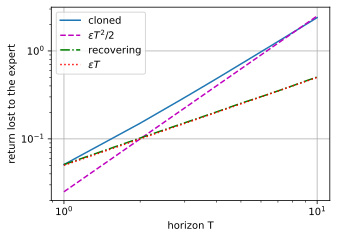

In [9]:
eps, T_max = 0.05, 10
rng = np.random.default_rng(3)
wrong = rng.random((20000, T_max)) < eps
T = np.arange(1, T_max + 1)
gap_bc = T - np.cumprod(~wrong, axis=1).cumsum(axis=1).mean(axis=0)
gap_rec = T - (~wrong).cumsum(axis=1).mean(axis=0)
d2l.plot([T] * 4, [gap_bc, eps * T ** 2 / 2, gap_rec, eps * T],
         xlabel='horizon T', ylabel='return lost to the expert',
         legend=['cloned', '$\\varepsilon T^2/2$', 'recovering',
                 '$\\varepsilon T$'],
         xscale='log', yscale='log', figsize=(5, 3.5))
print(f'lost return at T={T_max}: cloned {gap_bc[-1]:.2f} '
      f'(eps T^2/2 = {eps * T_max ** 2 / 2:.2f}), '
      f'recovering {gap_rec[-1]:.2f} (eps T = {eps * T_max:.2f})')

On logarithmic axes, the two measurements follow lines with different slopes: the cloned imitator tracks the quadratic reference and the recovering imitator tracks the linear reference. Their gaps differ by a factor of five at $T = 10$. Panel (b) of the figure runs the same simulation at $\varepsilon = 0.01$ out to $T = 64$, where the gap between the rates has grown past thirtyfold.

![How per-step imitation errors accumulate over a horizon. (a) The expert's state distribution and the clone's drift apart along the horizon: a clone that errs with probability $\varepsilon = 0.2$ per step on the expert's states, and acts uniformly at random where it has no data, spreads over cells the expert never occupies; after the marked first mistake the classification guarantee says nothing. (b) The return lost to the expert on the chain, simulated at $\varepsilon = 0.01$ with 20,000 rollouts per point: cloning tracks the quadratic reference $\varepsilon T^2/2$ while an imitator that recovers in one step tracks the linear reference $\varepsilon T$.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-compounding-error.svg)

### The Divergence of the State Distributions

The classifier satisfies its training objective, so the failure need not arise from optimization or model capacity. It arises because the deployed state distribution differs from the demonstration distribution. For FrozenLake, both distributions can be propagated exactly through the transition kernel from the same start state:

after  3 steps: total variation 0.000
after  5 steps: total variation 0.004
after 10 steps: total variation 0.063
after 20 steps: total variation 0.227
mass in the hole at s=12 after 20 steps: expert 0.000, clone 0.221


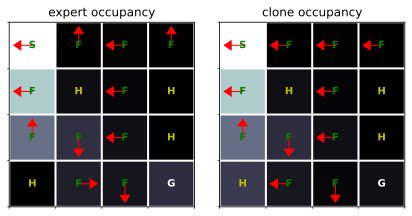

In [10]:
pi_clone = np.array([bc.act_greedy(s) for s in range(16)])
states = np.arange(16)
P_exp, P_clo = mdp.P[states, pi_star], mdp.P[states, pi_clone]
d_exp = d_clo = np.eye(16)[0]
occ_exp, occ_clo = np.zeros(16), np.zeros(16)
for t in range(1, 21):
    d_exp, d_clo = d_exp @ P_exp, d_clo @ P_clo
    occ_exp, occ_clo = occ_exp + d_exp, occ_clo + d_clo
    if t in (3, 5, 10, 20):
        print(f'after {t:>2} steps: total variation '
              f'{0.5 * np.abs(d_exp - d_clo).sum():.3f}')
print(f'mass in the hole at s=12 after 20 steps: '
      f'expert {d_exp[12]:.3f}, clone {d_clo[12]:.3f}')
d2l.show_grid(env.unwrapped.desc, np.stack([occ_exp, occ_clo]) / 20,
              np.stack([pi_star, pi_clone]),
              titles=['expert occupancy', 'clone occupancy'])

The distributions are identical for the first three steps because the clone agrees with the expert on all states reached that early. They then diverge as slippery transitions reach states absent from the demonstrations. By step 20, the clone assigns 22 percent probability to the hole at state 12, whereas the expert assigns none. The occupancy maps localize the difference near state 13, where the clone chooses the wrong action. Thus zero error on demonstrated states does not ensure small error on the distribution induced by the learned policy.

## Interactive Data Collection

### DAgger: Dataset Aggregation

The linear bound applies when the error is controlled under the learner's state distribution. DAgger obtains training data from that distribution [@Ross.Gordon.Bagnell.2011]: it executes the current learner, asks the expert to label the visited states, adds these pairs to the accumulated dataset, and refits the policy.

In [11]:
def relabel(ac, num_episodes):
    """Roll the learner; label its states with the expert's action."""
    visited = []
    for _ in range(num_episodes):
        s, done = env.reset()[0], False
        while not done:
            visited.append(s)
            s, reward, terminated, truncated, _ = env.step(ac.act_greedy(s))
            done = terminated or truncated
    visited = np.array(visited)
    return visited, pi_star[visited]

env.reset(seed=4)
agg_s, agg_a = demo_s, demo_a
for k in range(4):
    dag, _ = clone(agg_s, agg_a)
    tab = np.array([dag.act_greedy(s) for s in range(16)])
    rate = d2l.evaluate(env, lambda s, rng: int(tab[s]), num_episodes=1000)
    print(f'round {k}: trained on {agg_s.size:>3} pairs, '
          f'success rate {rate:.1%}')
    new_s, new_a = relabel(dag, 3)
    agg_s, agg_a = (np.concatenate([agg_s, new_s]),
                    np.concatenate([agg_a, new_a]))

round 0: trained on  96 pairs, success rate 18.0%


round 1: trained on 188 pairs, success rate 72.0%


round 2: trained on 273 pairs, success rate 72.2%


round 3: trained on 426 pairs, success rate 71.9%


Round 0 is behavior cloning on the original 96 pairs. After one DAgger round, the learned policy matches the expert in this experiment. The model, loss, and optimizer are unchanged; the improvement comes from collecting labels on the learner's visited states. In particular, the new data include state 13, where the original policy often failed and the expert rarely visited. In this example, these learner-state labels correct an error that additional trajectories from the expert distribution may not cover.

One successful round on FrozenLake illustrates the mechanism but not the full DAgger guarantee. The theorem in [@Ross.Gordon.Bagnell.2011] assumes repeated data collection, a no-regret learner trained on the accumulated dataset, and, in the original analysis, a mixture of expert and learner policies during collection. It also requires continued access to the expert for labeling learner states. Retaining data from all preceding rounds prevents the fitted policy from depending only on its most recent trajectories. Exercise 4 compares behavior cloning and DAgger under an equal expert-query budget.

### Supervised Fine-Tuning and Offline RL

Supervised fine-tuning of a language model is an instance of behavior cloning: the context is the state, the next token is the action, and curated responses provide demonstrations. At deployment, the model conditions on contexts containing its own previous outputs, so distribution shift can accumulate over a long generation. that section returns to this setting. Behavior cloning is also a standard baseline in offline reinforcement learning because it can always be applied to a fixed dataset without further interaction; that section compares offline RL methods with this baseline.

### Modern Imitation Learning

Several extensions reduce the required form of expert supervision.

Generative adversarial imitation learning trains a discriminator to distinguish learner trajectories from expert trajectories and uses its output as a reward for reinforcement learning [@Ho.Ermon.2016]. Maximum-entropy inverse reinforcement learning infers a reward under which the demonstrations are approximately optimal and then plans with that reward [@Ziebart.Maas.Bagnell.ea.2008]. Diffusion policies model distributions over action sequences and can represent multimodal demonstrations, such as two valid paths around an obstacle [@Chi.Feng.Du.ea.2023]. In each case, performance must still be evaluated under the state distribution induced by the learned policy.

## Summary

Behavior cloning fits $\pi_\theta(a\mid s)$ to demonstrated state--action pairs by cross-entropy and requires neither a transition model nor a reward. Its supervised guarantee applies to the expert's state distribution, whereas deployment evaluates the policy on states generated by its own actions. A per-step error $\varepsilon$ under the expert distribution can therefore produce a return gap of order $\varepsilon T^2$ over horizon $T$; controlling the error under the learner distribution yields an order-$\varepsilon T$ bound.

DAgger collects states from the learner and obtains expert labels for them, addressing this distribution mismatch when used iteratively with a no-regret learner. The section also introduced the `ActorCritic` container and the weighted log-likelihood update `policy_step`, for which behavior cloning uses unit weights.

**Experimental scope.** The reported fits and evaluations are reproducible from the stated seeds. The large gap between training accuracy and deployed performance comes from one small demonstration set; the ten-dataset comparison shows how often similar failures occur. The chain experiment constructs the two limiting error-propagation cases, while practical tasks generally fall between them. that section considers the setting without an expert.

## Exercises

1. [conceptual] *Where the bound comes from.* Reproduce the $O(\varepsilon T^2)$
   argument and identify the one step where "the expert's distribution" is
   replaced by "the learner's".
1. [short-code] *How many demonstrations.* Return against
   $N \in \{5, 20, 100, 500\}$; at what $N$ does the clone match the expert on
   the *expert's* states while still losing return?
1. [short-code] *Where the errors are.* Plot the clone's per-state error
   against the expert's state-visitation frequency; explain the shape.
1. [short-code] *DAgger's budget.* DAgger queries the expert on the learner's
   states. Count expert queries and compare like for like against BC at the
   same query budget.
1. [conceptual] *SFT is behavior cloning.* Write the correspondence for a
   language model, and say which term of the $O(\varepsilon T^2)$ bound explains
   why a model that has only ever been fine-tuned on gold responses degrades
   over long generations.
1. [extended] *A bad expert.* Corrupt 10% of the demonstrations; does BC or
   DAgger degrade faster, and why?

[Discussions](https://d2l.discourse.group/)